In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import pandas as pd

path_prefix = '/content/drive/MyDrive/KOPIS/Hyeon/'

file_paid_complex = path_prefix + 'DPI_ranked_Paid.csv'
file_paid_noncomplex = path_prefix + 'DPI_ranked_Paid_noncomplex.csv'
file_free_complex = path_prefix + 'DPI_ranked_Free.csv'
file_free_noncomplex = path_prefix + 'DPI_ranked_Free_noncomplex.csv'


df_paid_complex = pd.read_csv(file_paid_complex)
df_paid_noncomplex = pd.read_csv(file_paid_noncomplex)
df_free_complex = pd.read_csv(file_free_complex)
df_free_noncomplex = pd.read_csv(file_free_noncomplex)



In [ ]:
# 복합 공연
def prepare_complex_df(df):
    return df.dropna(subset=['공연시설명', '장르1', '장르2', 'DPI_region_adj_seg'])

# 단일 공연
def prepare_noncomplex_group(df):
    df = df.dropna(subset=['공연시설명', '장르명', 'DPI_region_adj_seg']).copy()
    df['장르1'] = df['장르명']
    return df.groupby(['공연시설명', '장르1'])['DPI_region_adj_seg'].mean().reset_index().rename(
        columns={'장르1': '장르명', 'DPI_region_adj_seg': '단일장르_평균_DPI'}
    )


In [ ]:
# 단일 공연 평균 DPI 매핑
def map_single_genre_dpi(df_complex, grouped_df, genre_col):
    return df_complex.apply(
        lambda row: grouped_df[
            (grouped_df['공연시설명'] == row['공연시설명']) &
            (grouped_df['장르명'] == row[genre_col])
        ]['단일장르_평균_DPI'].values[0] if not grouped_df[
            (grouped_df['공연시설명'] == row['공연시설명']) &
            (grouped_df['장르명'] == row[genre_col])
        ].empty else None,
        axis=1
    )

# 복합 공연 우세 판단 함수
def is_significant(row):
    genre1_dpi = row['장르1_단일DPI']
    genre2_dpi = row['장르2_단일DPI']
    complex_dpi = row['DPI_region_adj_seg']

    if pd.isna(genre1_dpi) and pd.isna(genre2_dpi):
        return False
    if pd.notna(genre1_dpi) and complex_dpi > genre1_dpi:
        return True
    if pd.notna(genre2_dpi) and complex_dpi > genre2_dpi:
        return True
    return False


In [ ]:
# 복합 vs 단일 비교 수행
def analyze_complex_vs_single(df_complex_raw, df_noncomplex_raw):
    df_complex = prepare_complex_df(df_complex_raw)
    df_noncomplex_group = prepare_noncomplex_group(df_noncomplex_raw)

    df_complex = df_complex.copy()
    df_complex['장르1_단일DPI'] = map_single_genre_dpi(df_complex, df_noncomplex_group, '장르1')
    df_complex['장르2_단일DPI'] = map_single_genre_dpi(df_complex, df_noncomplex_group, '장르2')
    df_complex['복합공연_우세'] = df_complex.apply(is_significant, axis=1)

    # 요약 통계
    valid = df_complex[['장르1_단일DPI', '장르2_단일DPI']].dropna(how='all').shape[0]
    count = df_complex['복합공연_우세'].sum()
    ratio = (count / valid * 100) if valid > 0 else 0

    return df_complex, {
        '비교 가능한 복합 공연 수': valid,
        '복합 공연 우세 수': int(count),
        '복합 공연 우세 비율 (%)': round(ratio, 2)
    }


In [ ]:

df_paid_result, paid_summary = analyze_complex_vs_single(df_paid_complex, df_paid_noncomplex)
df_free_result, free_summary = analyze_complex_vs_single(df_free_complex, df_free_noncomplex)

print("✅ 유료 공연 분석 결과:", paid_summary)
print("✅ 무료 공연 분석 결과:", free_summary)


✅ 유료 공연 분석 결과: {'비교 가능한 복합 공연 수': 242, '복합 공연 우세 수': 159, '복합 공연 우세 비율 (%)': np.float64(65.7)}
✅ 무료 공연 분석 결과: {'비교 가능한 복합 공연 수': 75, '복합 공연 우세 수': 36, '복합 공연 우세 비율 (%)': np.float64(48.0)}


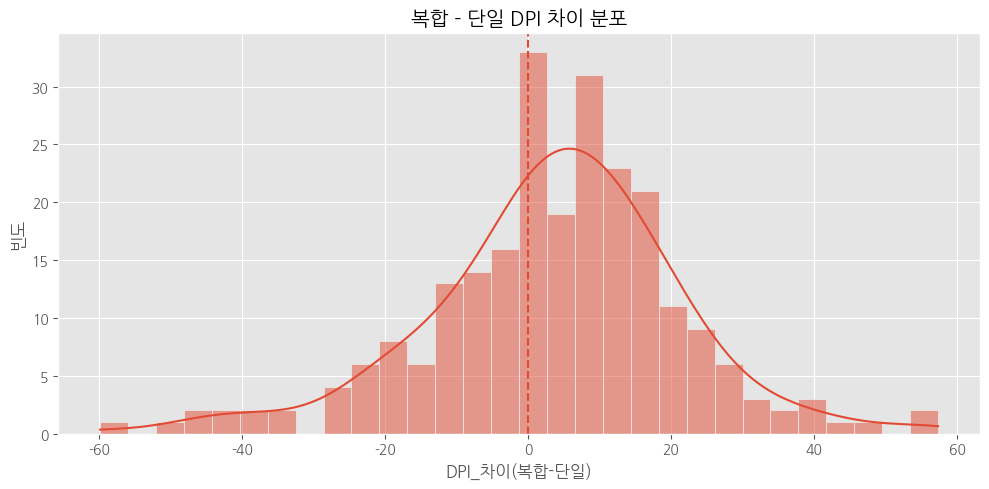

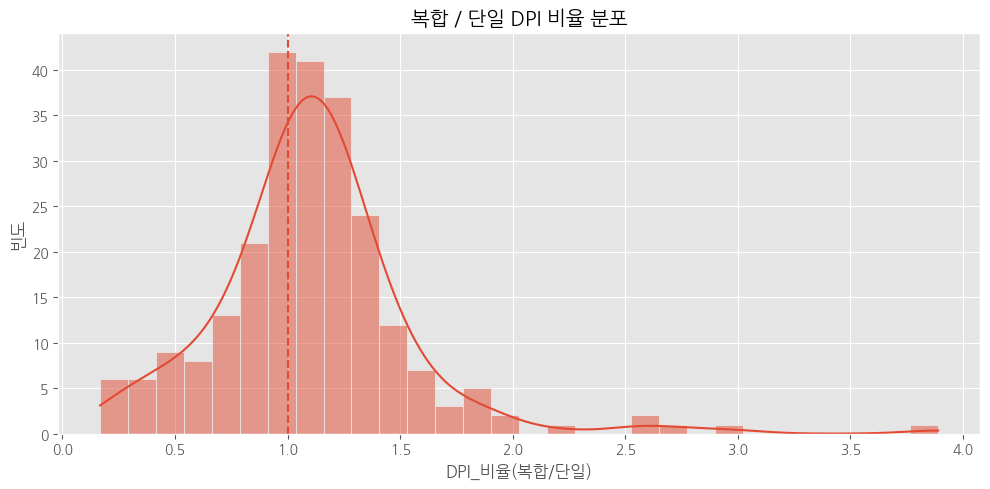

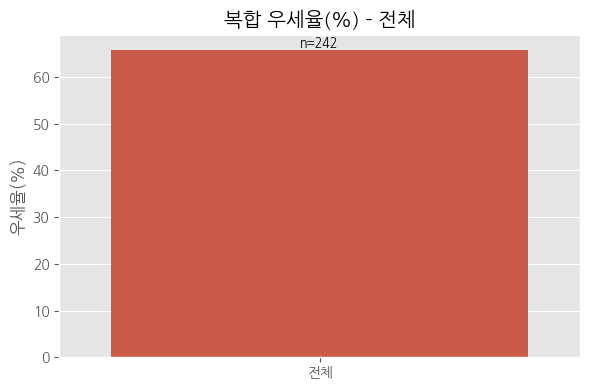

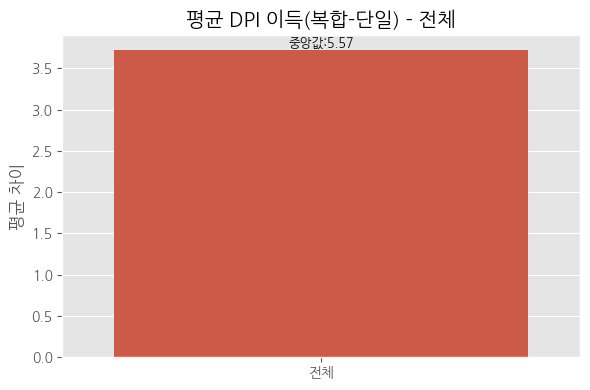

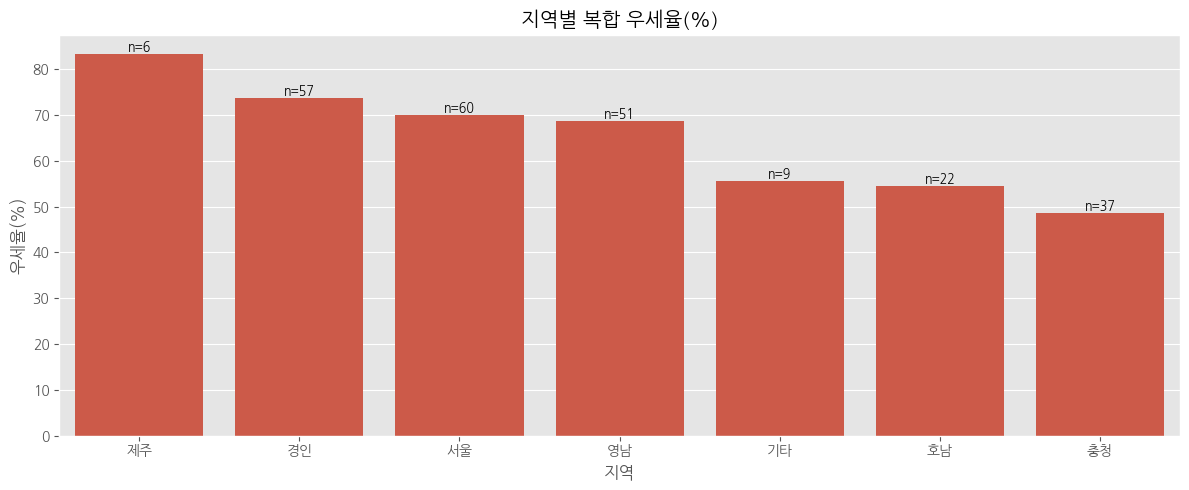

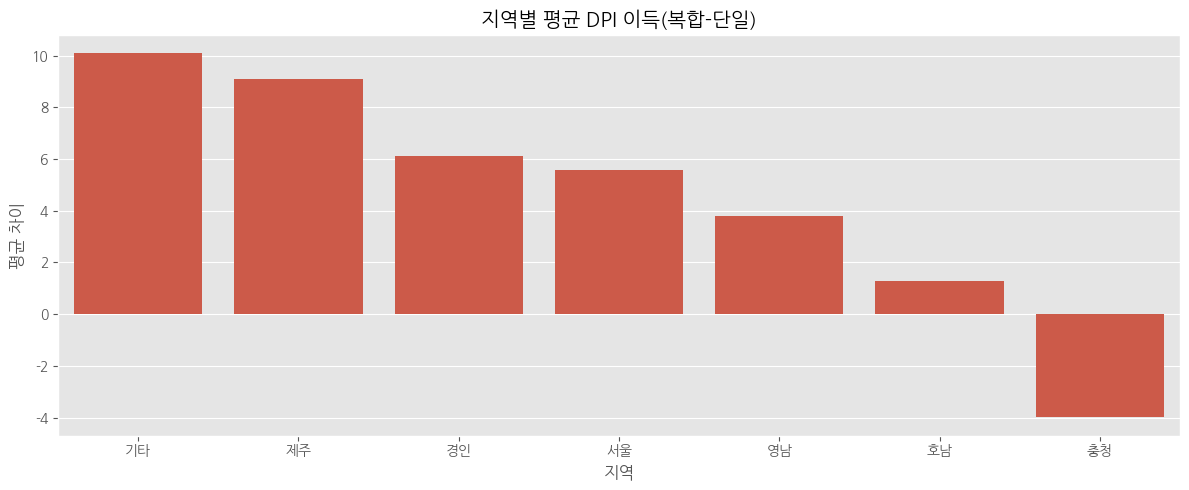

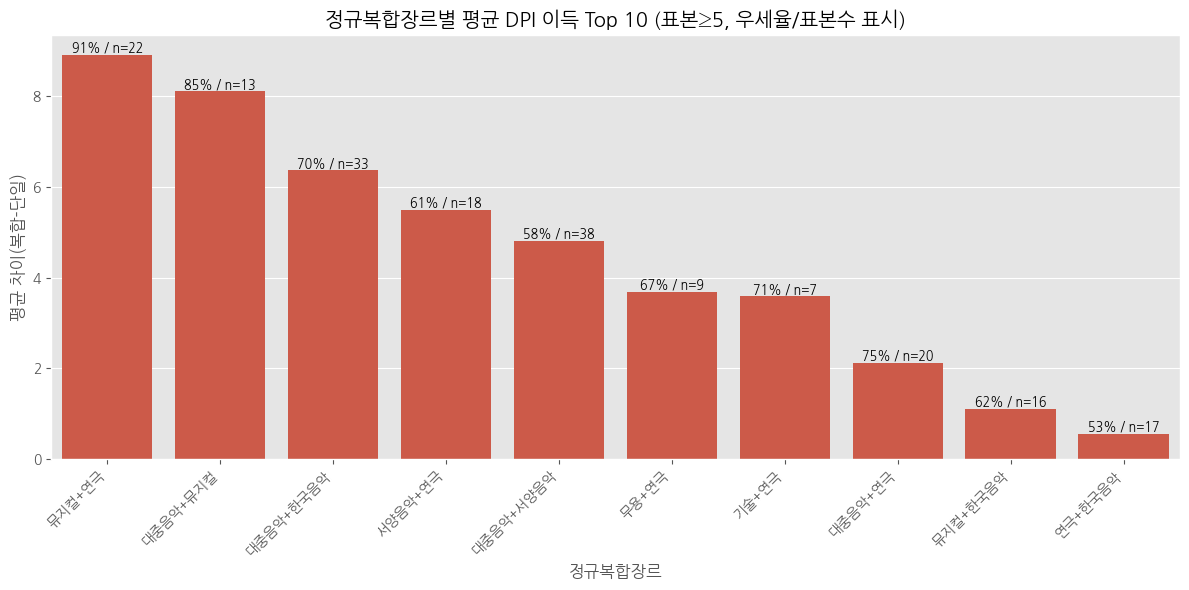

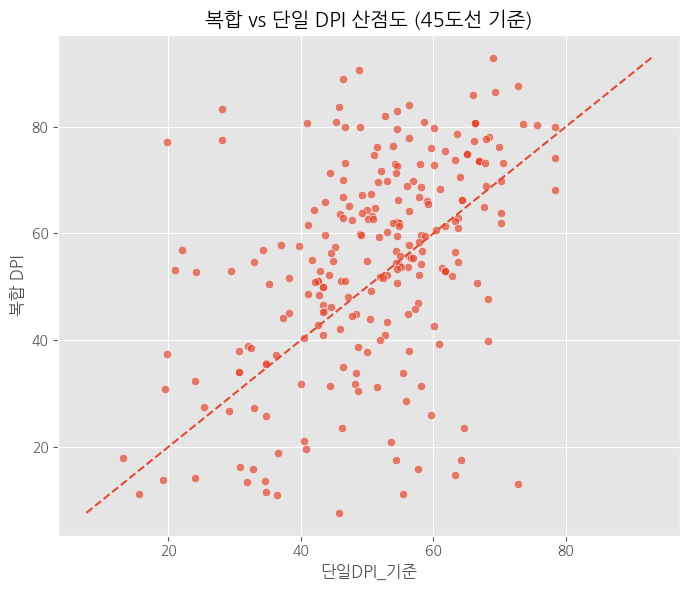

🏆 복합 우세 폭 상위 10건


,공연명,지역,공연시설명,예측복합장르,장르1,장르2,단일DPI_기준,DPI_region_adj_seg,DPI_차이(복합-단일)
50,서커스 클래식,서울,송파어린이문화회관,연극+한국음악,연극,한국음악,19.855491,77.218719,57.363228
16,홍지민과 함께하는 판타스틱쇼 시즌2,기타,삼척문화예술회관,뮤지컬+서양음악,뮤지컬,서양음악,28.055294,83.356076,55.300782
48,"XR 공연, 도채비 [제주]",제주,BeIN(비인),연극 + 기술,연극,기술,28.176242,77.434141,49.257899
2,빨간풍선,경인,남동소래아트홀,대중음악+연극,대중음악,연극,46.366714,89.006199,42.639484
1,FINEDAY FESTIVAL,서울,서울어린이대공원,대중음악+한국음악,대중음악,한국음악,48.831371,90.535258,41.703887
27,"3rd GPD FORUM 예술뉴런 뮤지카, with 권은비, 프라우드먼",서울,상명아트센터,대중음악+서양음악,대중음악,서양음악,40.911539,80.670513,39.758974
15,페페의 꿈 [춘천],기타,춘천인형극장,연극+뮤지컬,연극,뮤지컬,45.777557,83.645024,37.867467
21,페페의 꿈 [상주],영남,상주문화회관,뮤지컬+연극,뮤지컬,연극,45.246541,80.875349,35.628808
216,페페의 꿈 [부산],영남,금정문화회관,뮤지컬+연극,뮤지컬,연극,22.047316,56.943011,34.895696
33,김영임 & 김용임과 함께하는 희희낙락 [문경],영남,문경문화예술회관,한국음악+대중음악,한국음악,대중음악,46.643997,79.959628,33.315631



⚠️ 복합 열세 폭 상위 10건


,공연명,지역,공연시설명,예측복합장르,장르1,장르2,단일DPI_기준,DPI_region_adj_seg,DPI_차이(복합-단일)
454,국립극장 달빛 상영회,서울,국립극장,한국음악+연극,한국음악,연극,72.826156,12.977878,-59.848278
449,"고스트쉽, 코마 [세종]",충청,세종예술의전당,연극 + 기술,연극,기술,63.345747,14.657294,-48.688453
442,하우스콘서트 아리아리동동(同同) [함양],영남,함양문화예술회관,연극+대중음악,연극,대중음악,64.182988,17.565536,-46.617452
461,PIUM Project 크리스마스 스페셜 콘서트 [대전],충청,대전예술의전당,서양음악+대중음악,서양음악,대중음악,55.449643,11.122198,-44.327446
446,깽판: 우리가 살판 [양주],경인,양주문화예술회관,뮤지컬+한국음악,뮤지컬,한국음악,57.710019,15.814143,-41.895876
421,"제896회 전남도립국악단 토요가무악희 시즌3, 그린국악",호남,남도소리울림터,뮤지컬+한국음악,뮤지컬,한국음악,64.577437,23.593591,-40.983846
471,키즈 마티네 콘서트 [김포],경인,김포아트홀,뮤지컬+무용,뮤지컬,무용,45.818139,7.663124,-38.155015
443,주창회 정기연주회: 현대음악 그리고 사계예찬 [대전],충청,대전예술의전당,서양음악+뮤지컬,서양음악,뮤지컬,54.413866,17.488922,-36.924945
414,온가족이 함께하는 유모차 콘서트 [대전],충청,조이마루아트홀 (복합문화공간 플랜에이),서양음악+연극,서양음악,연극,59.720070,26.060817,-33.659253
431,"중섭, 빛깔 있는 꿈 [서귀포]",제주,김정문화회관,연극 + 기술,연극,기술,53.546078,20.977613,-32.568465


In [ ]:
# =========================
# 복합 vs 단일 DPI 비교 시각화
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ---- 0) 필수 컬럼 체크 & 복사 (공연유형 제거)
required_cols = [
    '지역','공연시설명','예측복합장르','장르1','장르2',
    'DPI_region_adj_seg','장르1_단일DPI','장르2_단일DPI','복합공연_우세'
]
missing = [c for c in required_cols if c not in df_paid_result.columns]
if missing:
    raise ValueError(f"df_paid_result에 다음 컬럼이 필요합니다: {missing}")

dfc = df_paid_result.copy()

# ---- 1) 파생지표: 단일 기준, 이득(차이/비율), 정규화된 복합장르
dfc['단일DPI_기준'] = dfc[['장르1_단일DPI', '장르2_단일DPI']].max(axis=1)

# 비교 가능한 샘플(단일값이 하나라도 있는 경우)
dfc_valid = dfc[~dfc[['장르1_단일DPI', '장르2_단일DPI']].isna().all(axis=1)].copy()

# 이득(차이, 비율)
dfc_valid['DPI_차이(복합-단일)'] = dfc_valid['DPI_region_adj_seg'] - dfc_valid['단일DPI_기준']
dfc_valid['DPI_비율(복합/단일)'] = dfc_valid['DPI_region_adj_seg'] / dfc_valid['단일DPI_기준']
dfc_valid['DPI_비율(복합/단일)'] = dfc_valid['DPI_비율(복합/단일)'].replace([np.inf, -np.inf], np.nan)

# 정규화된 복합 장르 조합
def normalize_pair(r):
    return '+'.join(sorted([str(r['장르1']), str(r['장르2'])]))
dfc_valid['정규복합장르'] = dfc_valid.apply(normalize_pair, axis=1)

# ---- 2) 전체 분포: 복합이 단일 대비 얼마나 이겼나?
plt.figure(figsize=(10,5))
sns.histplot(dfc_valid['DPI_차이(복합-단일)'].dropna(), bins=30, kde=True)
plt.axvline(0, linestyle='--')
plt.title('복합 - 단일 DPI 차이 분포')
plt.xlabel('DPI_차이(복합-단일)'); plt.ylabel('빈도')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
sns.histplot(dfc_valid['DPI_비율(복합/단일)'].dropna(), bins=30, kde=True)
plt.axvline(1.0, linestyle='--')
plt.title('복합 / 단일 DPI 비율 분포')
plt.xlabel('DPI_비율(복합/단일)'); plt.ylabel('빈도')
plt.tight_layout(); plt.show()

# ---- 3) (공연유형 대신) 전체 요약 우세율 & 평균 이득
overall = pd.DataFrame({
    '우세율(%)': [round(100 * dfc_valid['복합공연_우세'].mean(), 2)],
    '표본수': [int(dfc_valid.shape[0])],
    '평균_차이': [dfc_valid['DPI_차이(복합-단일)'].mean()],
    '중앙값_차이': [dfc_valid['DPI_차이(복합-단일)'].median()]
})

plt.figure(figsize=(6,4))
ax = sns.barplot(data=overall.assign(구분='전체'), x='구분', y='우세율(%)')
for p, r in zip(ax.patches, overall.itertuples()):
    ax.text(p.get_x()+p.get_width()/2, p.get_height(), f"n={r.표본수}", ha='center', va='bottom', fontsize=9)
plt.title('복합 우세율(%) - 전체')
plt.xlabel(''); plt.ylabel('우세율(%)')
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
ax = sns.barplot(data=overall.assign(구분='전체'), x='구분', y='평균_차이')
for p, r in zip(ax.patches, overall.itertuples()):
    ax.text(p.get_x()+p.get_width()/2, p.get_height(), f"중앙값:{r.중앙값_차이:.2f}", ha='center', va='bottom', fontsize=9)
plt.title('평균 DPI 이득(복합-단일) - 전체')
plt.xlabel(''); plt.ylabel('평균 차이')
plt.tight_layout(); plt.show()

# ---- 4) 지역별 우세율 & 평균 차이
by_region = (
    dfc_valid.dropna(subset=['지역'])
    .groupby('지역', dropna=False)
    .agg(
        우세율=('복합공연_우세', lambda x: round(100 * x.mean(), 2)),
        표본수=('복합공연_우세', 'size'),
        평균_차이=('DPI_차이(복합-단일)', 'mean')
    )
    .reset_index()
)

plt.figure(figsize=(12,5))
ax = sns.barplot(data=by_region.sort_values('우세율', ascending=False), x='지역', y='우세율')
for p, r in zip(ax.patches, by_region.sort_values('우세율', ascending=False).itertuples()):
    ax.text(p.get_x()+p.get_width()/2, p.get_height(), f"n={r.표본수}", ha='center', va='bottom', fontsize=9)
plt.title('지역별 복합 우세율(%)'); plt.xlabel('지역'); plt.ylabel('우세율(%)')
plt.tight_layout(); plt.show()

plt.figure(figsize=(12,5))
sns.barplot(data=by_region.sort_values('평균_차이', ascending=False), x='지역', y='평균_차이')
plt.title('지역별 평균 DPI 이득(복합-단일)'); plt.xlabel('지역'); plt.ylabel('평균 차이')
plt.tight_layout(); plt.show()

# ---- 5) 정규복합장르 Top N: 평균 이득 & 우세율 (표본수 필터 포함)
min_n = 5  # 표본수 최소 기준(필요시 조정)
genre_stats = (
    dfc_valid
    .groupby('정규복합장르', dropna=False)
    .agg(
        우세율=('복합공연_우세', lambda x: 100 * x.mean()),
        표본수=('복합공연_우세', 'size'),
        평균_차이=('DPI_차이(복합-단일)', 'mean')
    )
    .reset_index()
)
genre_stats = genre_stats[genre_stats['표본수'] >= min_n].sort_values('평균_차이', ascending=False)

topN = 10
plt.figure(figsize=(12,6))
top_df = genre_stats.head(topN)
ax = sns.barplot(data=top_df, x='정규복합장르', y='평균_차이')
for p, r in zip(ax.patches, top_df.itertuples()):
    ax.text(p.get_x()+p.get_width()/2, p.get_height(), f"{r.우세율:.0f}% / n={int(r.표본수)}",
            ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.title(f'정규복합장르별 평균 DPI 이득 Top {topN} (표본≥{min_n}, 우세율/표본수 표시)')
plt.ylabel('평균 차이(복합-단일)'); plt.xlabel('정규복합장르')
plt.tight_layout(); plt.show()

# ---- 6) 산점도: 단일 기준 vs 복합 (공연유형 hue 제거, 45도선 포함)
scatter = dfc_valid[['단일DPI_기준','DPI_region_adj_seg']].replace([np.inf, -np.inf], np.nan).dropna()
plt.figure(figsize=(7,6))
sns.scatterplot(data=scatter, x='단일DPI_기준', y='DPI_region_adj_seg', alpha=0.7)
lims = [
    min(scatter['단일DPI_기준'].min(), scatter['DPI_region_adj_seg'].min()),
    max(scatter['단일DPI_기준'].max(), scatter['DPI_region_adj_seg'].max())
]
plt.plot([lims[0], lims[1]], [lims[0], lims[1]], linestyle='--')
plt.title('복합 vs 단일 DPI 산점도 (45도선 기준)')
plt.xlabel('단일DPI_기준'); plt.ylabel('복합 DPI')
plt.tight_layout(); plt.show()

# ---- 7) 상/하위 사례 테이블
cols_show = ['공연명','지역','공연시설명','예측복합장르','장르1','장르2','단일DPI_기준','DPI_region_adj_seg','DPI_차이(복합-단일)']
top_gain = dfc_valid.sort_values('DPI_차이(복합-단일)', ascending=False).head(10)[cols_show]
worst_gain = dfc_valid.sort_values('DPI_차이(복합-단일)', ascending=True).head(10)[cols_show]

try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
except Exception:
    pass

print('🏆 복합 우세 폭 상위 10건')
display(top_gain)
print('\n⚠️ 복합 열세 폭 상위 10건')
display(worst_gain)


In [ ]:
!apt-get update -qq
!apt-get install -y fonts-nanum

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
import os

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')
    plt.rcParams['axes.unicode_minus'] = False
else:
    print("폰트 파일이 존재하지 않습니다.")


plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


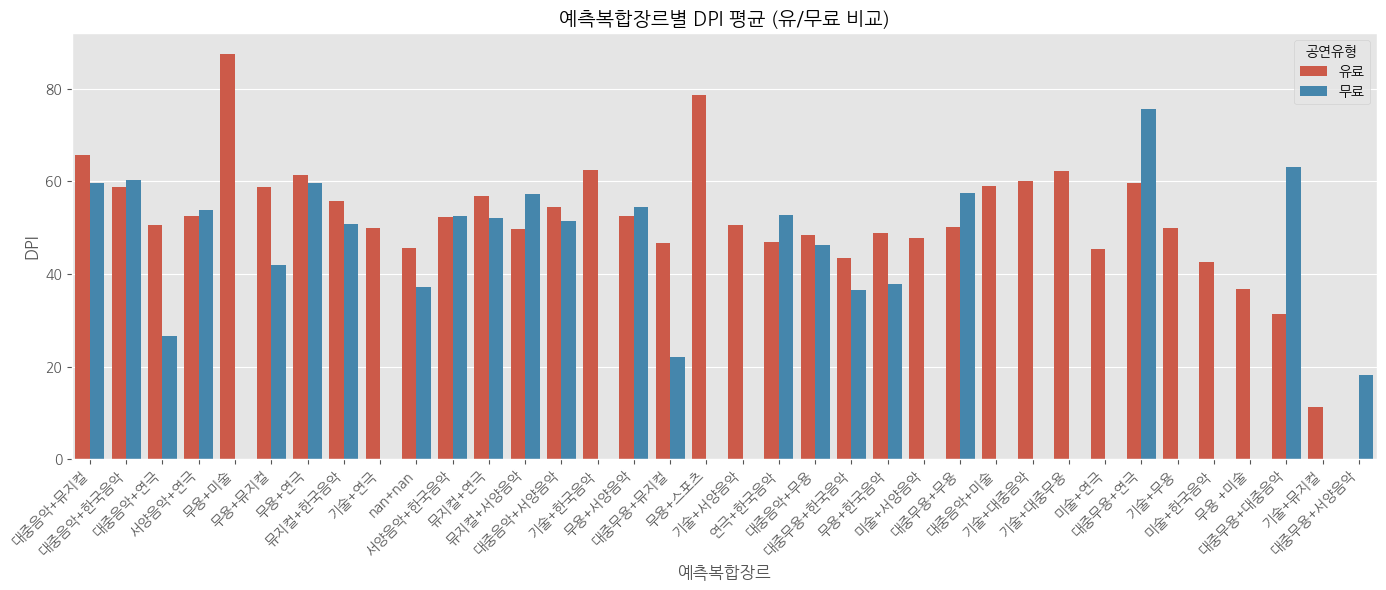

In [ ]:

columns = [
    "예측복합장르", "장르1", "장르2",
    "DPI_region_adj_seg", "DPI_plus",
    "S_scale", "A_afford", "최종_좌석점유율", "총_공연회차_계산", "평균판매단가", "회차당매출"
]


df_paid_complex['공연유형'] = '유료'
df_free_complex['공연유형'] = '무료'


df = pd.concat([
    df_paid_complex[columns + ['공연유형']],
    df_free_complex[columns + ['공연유형']]
], ignore_index=True)


plt.style.use('ggplot')
plt.rcParams['font.family'] = 'NanumGothic'  # 한글 깨질 경우: 'NanumGothic' 또는 코랩에 폰트 설치 필요

# 장르 조합 정규화
def normalize_genre_pair(row):
    genres = sorted([str(row['장르1']), str(row['장르2'])])
    return '+'.join(genres)

df['정규복합장르'] = df.apply(normalize_genre_pair, axis=1)

# 정규화된 복합 장르 조합별 DPI_region_adj_seg 평균 시각화
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df,
    x='정규복합장르',
    y='DPI_region_adj_seg',
    hue='공연유형',
    errorbar= None
    # estimator='mean'
)
plt.title('예측복합장르별 DPI 평균 (유/무료 비교)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('DPI')
plt.xlabel('예측복합장르')
plt.tight_layout()
plt.show()

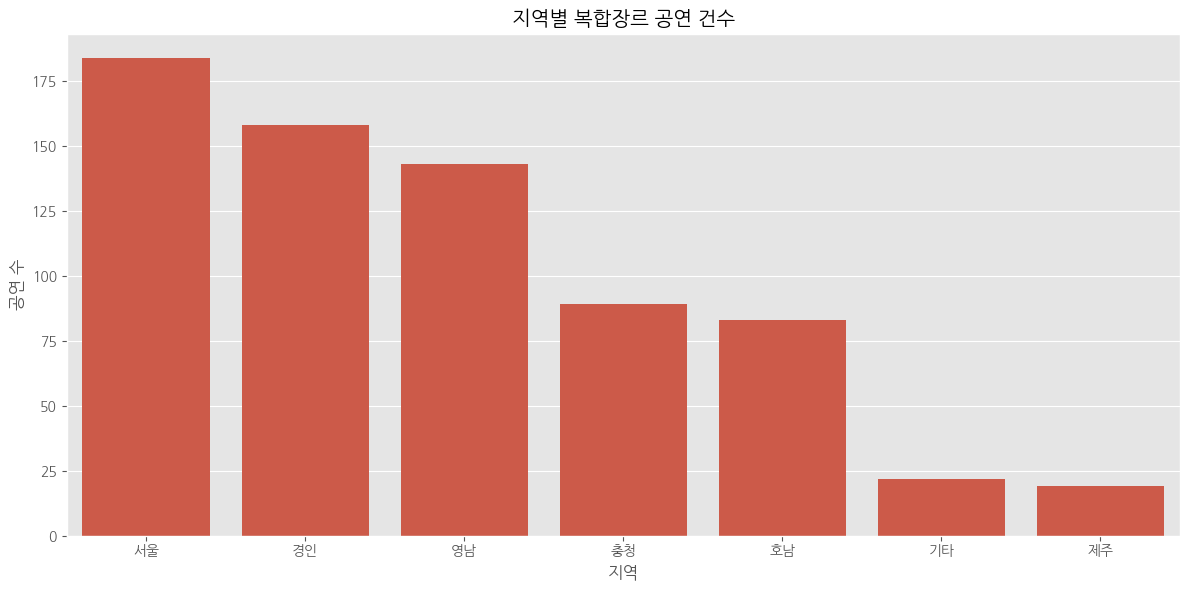

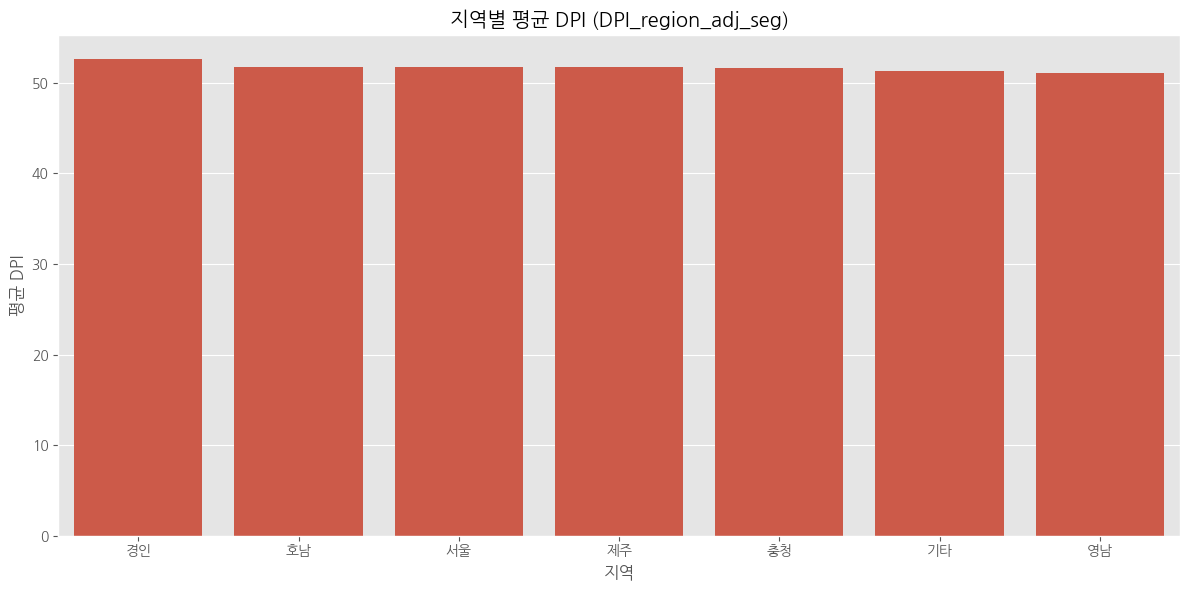

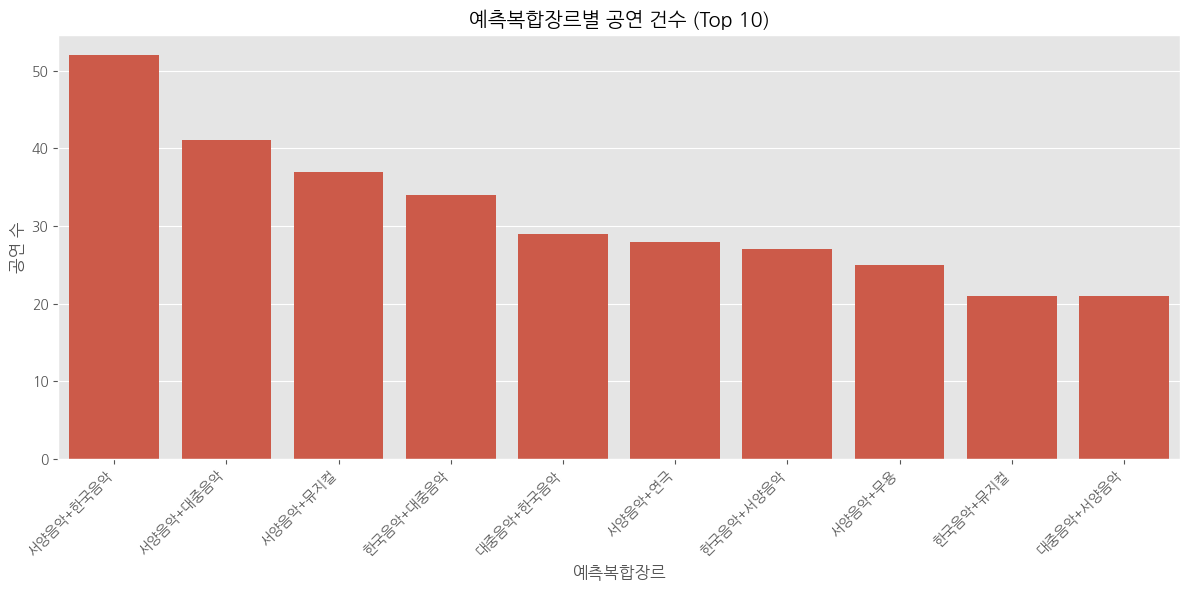

In [ ]:
# ========================
# 지역별/예측복합장르별 분석 추가
# ========================

# 지역별 복합장르 공연 건수
region_counts = (
    df.groupby('지역')
    .size()
    .reset_index(name='공연수')
    .sort_values('공연수', ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=region_counts, x='지역', y='공연수')
plt.title('지역별 복합장르 공연 건수')
plt.xlabel('지역')
plt.ylabel('공연 수')
plt.tight_layout()
plt.show()

# 지역별 평균 DPI (DPI_region_adj_seg)
region_dpi = (
    df.groupby('지역')['DPI_region_adj_seg']
    .mean()
    .reset_index()
    .sort_values('DPI_region_adj_seg', ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=region_dpi, x='지역', y='DPI_region_adj_seg')
plt.title('지역별 평균 DPI (DPI_region_adj_seg)')
plt.xlabel('지역')
plt.ylabel('평균 DPI')
plt.tight_layout()
plt.show()

# 예측복합장르별 공연 건수 (Top 10)
genre_counts = (
    df.groupby('예측복합장르')
    .size()
    .reset_index(name='공연수')
    .sort_values('공연수', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=genre_counts, x='예측복합장르', y='공연수')
plt.title('예측복합장르별 공연 건수 (Top 10)')
plt.xlabel('예측복합장르')
plt.ylabel('공연 수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


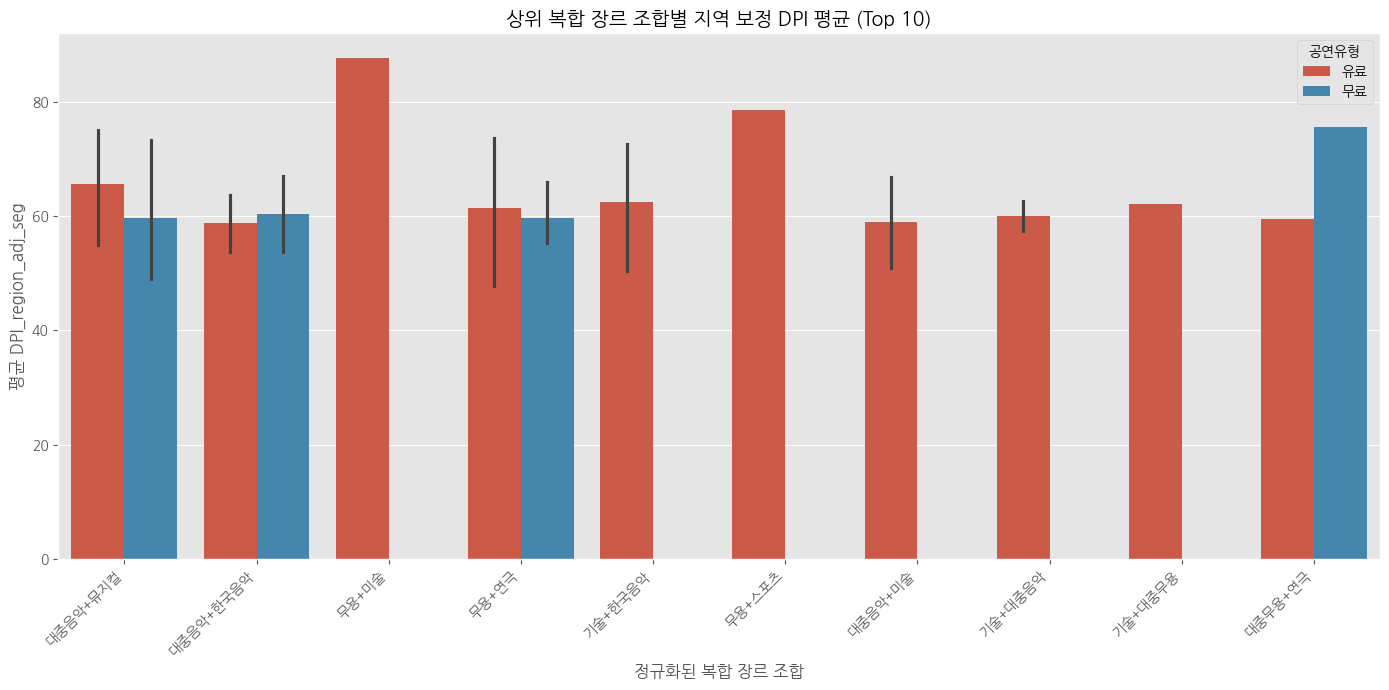

In [ ]:

df_paid_complex['공연유형'] = '유료'
df_free_complex['공연유형'] = '무료'

df = pd.concat([df_paid_complex, df_free_complex], ignore_index=True)

# 장르 정규화
def normalize_genre_pair(row):
    genres = sorted([str(row['장르1']), str(row['장르2'])])
    return '+'.join(genres)

df['정규복합장르'] = df.apply(normalize_genre_pair, axis=1)

# 상위 장르 조합 10개 선정 (DPI_region_adj_seg 평균 기준)
top_genres = (
    df.groupby('정규복합장르')['DPI_region_adj_seg']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# 시각화: 상위 장르 조합별 지역 보정 DPI 평균
plt.figure(figsize=(14, 7))
sns.barplot(
    data=df[df['정규복합장르'].isin(top_genres)],
    x='정규복합장르',
    y='DPI_region_adj_seg',
    hue='공연유형',
    errorbar='ci'
)
plt.title('상위 복합 장르 조합별 지역 보정 DPI 평균 (Top 10)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel('정규화된 복합 장르 조합')
plt.ylabel('평균 DPI_region_adj_seg')
plt.tight_layout()
plt.show()


# 복합 장르 시각화


/tmp/ipython-input-624168455.py:31: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=[dpi_paid, dpi_free], palette=['steelblue', 'salmon'])


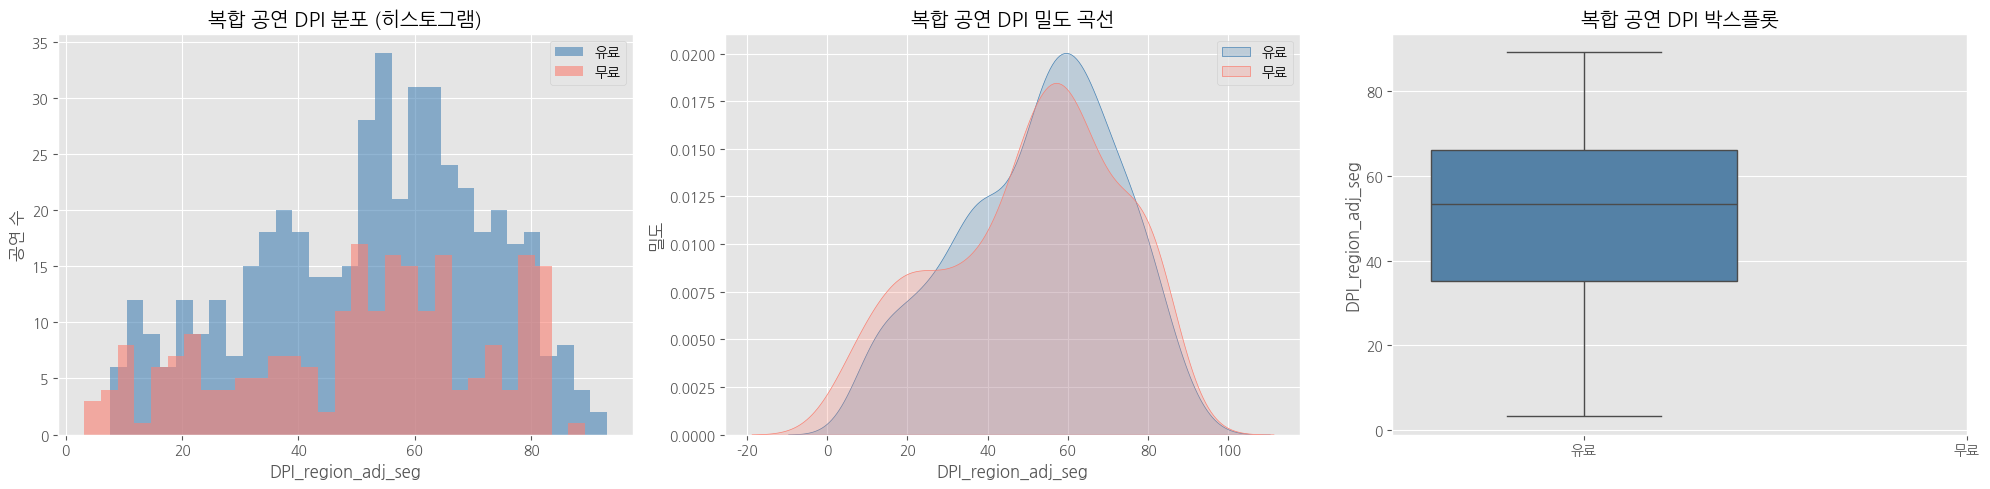

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# DPI 값만 있는 Series 추출
dpi_paid = df_paid_complex['DPI_region_adj_seg'].dropna()
dpi_free = df_free_complex['DPI_region_adj_seg'].dropna()

# 🎨 시각화 시작
plt.figure(figsize=(20, 5))

# ▶️ ① 히스토그램
plt.subplot(1, 3, 1)
plt.hist(dpi_paid, bins=30, alpha=0.6, label='유료', color='steelblue')
plt.hist(dpi_free, bins=30, alpha=0.6, label='무료', color='salmon')
plt.title('복합 공연 DPI 분포 (히스토그램)')
plt.xlabel('DPI_region_adj_seg')
plt.ylabel('공연 수')
plt.legend()

# ▶️ ② KDE 밀도 추정
plt.subplot(1, 3, 2)
sns.kdeplot(dpi_paid, label='유료', fill=True, color='steelblue')
sns.kdeplot(dpi_free, label='무료', fill=True, color='salmon')
plt.title('복합 공연 DPI 밀도 곡선')
plt.xlabel('DPI_region_adj_seg')
plt.ylabel('밀도')
plt.legend()

# ▶️ ③ 박스플롯
plt.subplot(1, 3, 3)
sns.boxplot(data=[dpi_paid, dpi_free], palette=['steelblue', 'salmon'])
plt.xticks([0, 1], ['유료', '무료'])
plt.title('복합 공연 DPI 박스플롯')
plt.ylabel('DPI_region_adj_seg')

plt.tight_layout()
plt.show()
